In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np

import hmmlearn.hmm as hmm

import matplotlib.colors as mcolors
import matplotlib.dates as mdates

import lissa as li

import statsmodels.api as sm

from sklearn.preprocessing import power_transform

import pickle




/tmp/ipykernel_119183/1436180417.py:18: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  PCAData = pd.read_csv("../data/PCA/PCAtotal.csv",delimiter=",").fillna(0)


In [15]:
PCAData = pd.read_csv("../data/PCA/PCAtotal.csv",delimiter=",").fillna(0)
PCAData.rename(columns={"Unnamed: 0":"time"},inplace=True)

pumpList = PCAData["Well Run"].unique()

complexVib = PCAData["ESP Vibration X"]+1j*PCAData["ESP Vibration Y"]

PCAData["VibMod"] = np.absolute(complexVib)

/tmp/ipykernel_119183/2553270337.py:1: DtypeWarning: Columns (14,15) have mixed types. Specify dtype option on import or set low_memory=False.
  PCAData = pd.read_csv("../data/PCA/PCAtotal.csv",delimiter=",").fillna(0)


In [34]:
n = [3, 5]

seeds = np.random.randint(low=971215,high=20000728,size=1)

medianListR = np.zeros(len(pumpList))
medianListV = np.zeros(len(pumpList))
for seed in seeds:
    X_train, trainLength, X_test, testLength, modelData, totalLength = li.Splitter(pumpList=pumpList,proportion=0.75,entireData=PCAData)
    pumpList = PCAData["Well Run"].unique()

    data = PCAData["Radius"].loc[PCAData["Well_down"]==0]

    gmm = li.GaussianMixtureFit(data,n[0],seed)

    modelRadius = li.HMMTrainer(X_train["Radius"],trainLength,li.StandardMarkovModel(n[0],seed,gmm))

    li.PostProcessing(modelRadius, PCAData, modelData,"Radius", "State Radius", totalLength)

    PCAData["State Radius"] = PCAData["State Radius"].map(li.StateConversion(modelRadius.get_stationary_distribution(),n[0]))



    data = PCAData["VibMod"].loc[(PCAData["VibMod"]!=0) & (PCAData["Well_down"]==0)].apply(np.log1p)

    gmm = li.GaussianMixtureFit(data,n[1],seed)
         
    modelVib = li.HMMTrainer(X_train["VibMod"].apply(np.log1p),trainLength,li.StandardMarkovModel(n[1],seed,gmm))

    li.PostProcessing(modelVib, PCAData, modelData,"VibMod", "State Mod", totalLength)
    
    PCAData["State Mod"] = PCAData["State Mod"].map(li.StateConversion(modelVib.get_stationary_distribution(),n[1]))

    PCAData.loc[(PCAData["VibMod"]==0) & (PCAData["Well_down"]==0),"State Mod"] = 5

    medianListR_G = np.array([])
    medianListV_G = np.array([])

    for pump in pumpList:
        pumpData = PCAData.loc[(PCAData["Well Run"]==pump) & (PCAData["Well_down"]==0) ]#.copy()
        last = pumpData.shape[0]
        pumpMedianR = pumpData.loc[pumpData.index[last-24:last-1],"State Radius"].median()
        pumpMedianV = pumpData.loc[pumpData.index[last-24:last-1],"State Mod"].median()
        medianListR_G = np.append(medianListR_G,pumpMedianR)
        medianListV_G = np.append(medianListV_G,pumpMedianV)

    medianListR += medianListR_G/len(seeds)
    medianListV += medianListV_G/len(seeds)

/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/ml.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  exportData = pd.concat([exportData,modelData],axis=0)
/home/kuga/Área de trabalho/equinor-pc/operational/lissa_pack/src/lissa/ml.py:38: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  exportData = pd.concat([exportData,modelData],axis=0)


AIC: 1834726.2036670975 BIC: 1834889.3017190022
AIC: -1587171.4450548973 BIC: -1586775.349785986


Text(0.5, 1.0, 'Histograma de Persistência de Estados - Energia PCA')

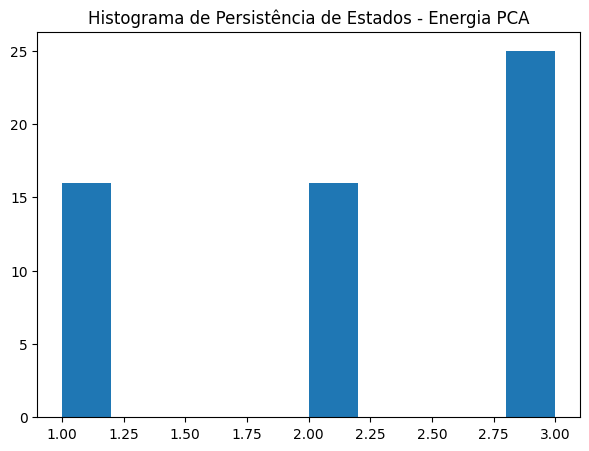

In [35]:
plt.figure(figsize=(7,5))
plt.hist(medianListR)
plt.title("Histograma de Persistência de Estados - Energia PCA")

Text(0.5, 1.0, 'Histograma de Persistência de Estados - Módulo da Vibração')

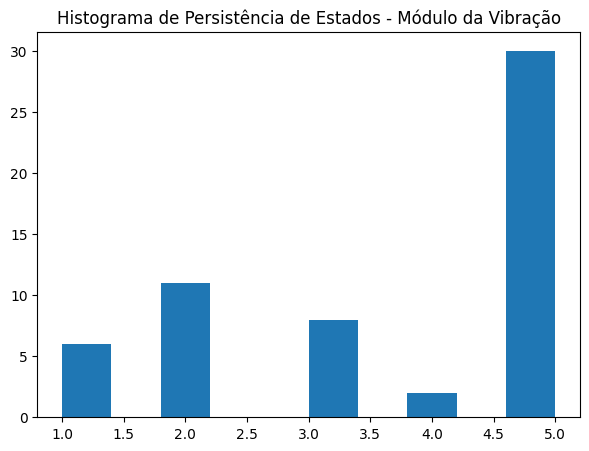

In [36]:
plt.figure(figsize=(7,5))
plt.hist(medianListV)
plt.title("Histograma de Persistência de Estados - Módulo da Vibração")